In [ ]:
# Name : Aishwarya Laxmikant Lonikar
# CS AI - D
# Roll No. 2
# Subject : Machine Learning
# PRN : 12410541

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv('/content/sample_data/uber.csv')
print(df.shape)
df.head()


(151965, 9)


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1.0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3.0
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5.0


In [ ]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 200)]

df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]

df = df[
    (df['pickup_latitude'].between(-90, 90)) &
    (df['dropoff_latitude'].between(-90, 90)) &
    (df['pickup_longitude'].between(-180, 180)) &
    (df['dropoff_longitude'].between(-180, 180))
]

df.shape


(151403, 9)

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

df['distance_km'] = haversine(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['dropoff_latitude'],
    df['dropoff_longitude']
)

df = df[(df['distance_km'] > 0) & (df['distance_km'] < 50)]

df.head()



,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0,1.683323
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0,2.457590
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1.0,5.036377
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3.0,1.661683
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5.0,4.475450


In [ ]:
def remove_outliers_iqr(data, cols):
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        data = data[(data[col] >= (Q1 - 1.5*IQR)) & (data[col] <= (Q3 + 1.5*IQR))]
    return data

df = remove_outliers_iqr(df, ['fare_amount', 'distance_km'])
df.shape


(128342, 10)

In [ ]:
numeric_df = df[[
    'fare_amount',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'passenger_count',
    'distance_km'
]]

# Pearson
pearson_corr = numeric_df.corr(method='pearson')

# Spearman
spearman_corr = numeric_df.corr(method='spearman')

# Kendall
kendall_corr = numeric_df.corr(method='kendall')

print("Pearson Correlation:\n", pearson_corr)
print("\nSpearman Correlation:\n", spearman_corr)
print("\nKendall Correlation:\n", kendall_corr)


Pearson Correlation:
                    fare_amount  pickup_longitude  pickup_latitude  \
fare_amount           1.000000          0.003857        -0.004421   
pickup_longitude      0.003857          1.000000        -0.993981   
pickup_latitude      -0.004421         -0.993981         1.000000   
dropoff_longitude     0.004255          0.999978        -0.993992   
dropoff_latitude     -0.004785         -0.993985         0.999971   
passenger_count       0.017278          0.009533        -0.009700   
distance_km           0.796032         -0.013382         0.011903   

                   dropoff_longitude  dropoff_latitude  passenger_count  \
fare_amount                 0.004255         -0.004785         0.017278   
pickup_longitude            0.999978         -0.993985         0.009533   
pickup_latitude            -0.993992          0.999971        -0.009700   
dropoff_longitude           1.000000         -0.993972         0.009537   
dropoff_latitude           -0.993972          1.00

In [ ]:
X = df[['distance_km', 'passenger_count']]
y = df['fare_amount']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.01)

lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)


Lasso(alpha=0.01)

In [ ]:
y_pred_lr = lr.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)


In [ ]:
def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(name)
    print("R2 Score:", r2)
    print("RMSE:", rmse)
    print("-"*40)
    return r2, rmse

r2_lr, rmse_lr = evaluate("Linear Regression", y_test, y_pred_lr)
r2_ridge, rmse_ridge = evaluate("Ridge Regression", y_test, y_pred_ridge)
r2_lasso, rmse_lasso = evaluate("Lasso Regression", y_test, y_pred_lasso)


Linear Regression
R2 Score: 0.6452096434630863
RMSE: 2.2252615627758354
----------------------------------------
Ridge Regression
R2 Score: 0.6452095776410585
RMSE: 2.225261769195231
----------------------------------------
Lasso Regression
R2 Score: 0.6451855804061459
RMSE: 2.2253370238006487
----------------------------------------


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'R2 Score': [r2_lr, r2_ridge, r2_lasso],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso]
})

results


,Model,R2 Score,RMSE
0,Linear Regression,0.645210,2.225262
1,Ridge Regression,0.645210,2.225262
2,Lasso Regression,0.645186,2.225337


In [ ]:
data = {
    'Study_Hours': [2.5, 4.1, 5.0, 6.5, 7.1, 8.0, 9.5],
    'Exam_Score': [55, 68, 72, 80, 88, 92, 98]
}
df = pd.DataFrame(data)

print(df)


   Study_Hours  Exam_Score
0          2.5          55
1          4.1          68
2          5.0          72
3          6.5          80
4          7.1          88
5          8.0          92
6          9.5          98


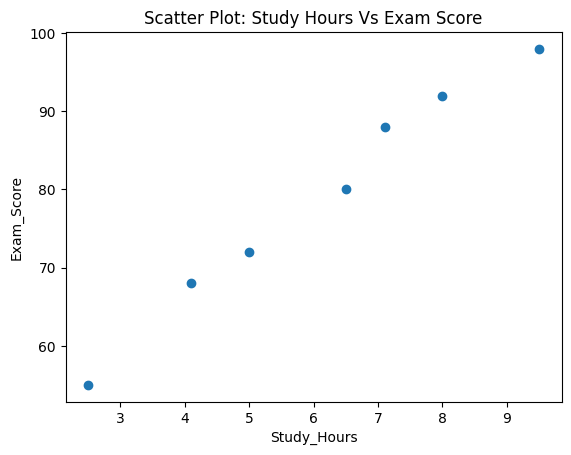

In [ ]:
plt.figure()
plt.scatter(df["Study_Hours"], df["Exam_Score"])
plt.xlabel("Study_Hours")
plt.ylabel("Exam_Score")
plt.title("Scatter Plot: Study Hours Vs Exam Score")

plt.show()

In [ ]:
X = df[['Study_Hours']]
y = df['Exam_Score']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 41.02086956521738
Slope: 6.22608695652174


In [ ]:
df['Predicted_Score'] = model.predict(X)
print(df)

   Study_Hours  Exam_Score  Predicted_Score
0          2.5          55        56.586087
1          4.1          68        66.547826
2          5.0          72        72.151304
3          6.5          80        81.490435
4          7.1          88        85.226087
5          8.0          92        90.829565
6          9.5          98       100.168696


In [ ]:
mse = mean_squared_error(y, df['Predicted_Score'])
r2 = r2_score(y, df['Predicted_Score'])

print("MSE:", mse)
print("R² Score:", r2)

MSE: 2.948074534161498
R² Score: 0.9848037395146314


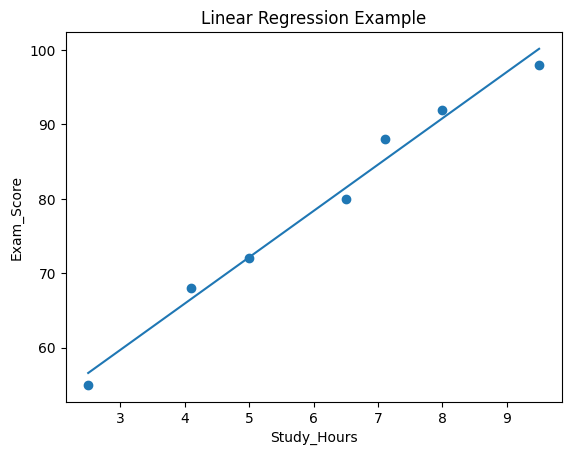

In [ ]:
plt.scatter(df['Study_Hours'], df['Exam_Score'])
plt.plot(df['Study_Hours'], df['Predicted_Score'])
plt.xlabel("Study_Hours")
plt.ylabel("Exam_Score")
plt.title("Linear Regression Example")
plt.show()

In [ ]:
df_csv = pd.read_csv("/content/sample_data/california_housing_test.csv")
df_csv

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
...,...,...,...,...,...,...,...,...,...
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0
2996,-118.14,34.06,27.0,5257.0,1082.0,3496.0,1036.0,3.3906,237200.0
2997,-119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0
2998,-117.12,34.10,40.0,96.0,14.0,46.0,14.0,3.2708,162500.0


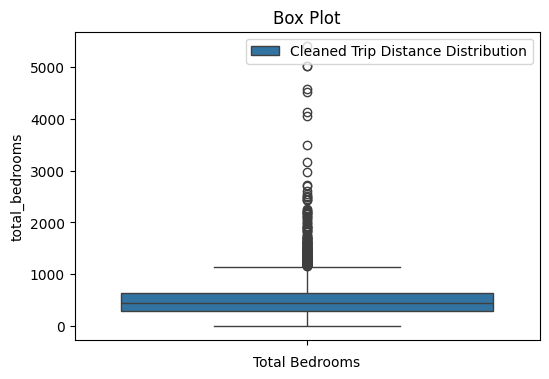

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(df_csv['total_bedrooms'])
plt.title("Box Plot")
plt.xlabel("Total Bedrooms")
plt.legend(["Cleaned Trip Distance Distribution"])


plt.show()

In [ ]:
data = df_csv[df_csv['households']<1000]
data = df_csv[df_csv['total_bedrooms']<1000]
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
...,...,...,...,...,...,...,...,...,...
2994,-117.93,33.86,35.0,931.0,181.0,516.0,174.0,5.5867,182500.0
2995,-119.86,34.42,23.0,1450.0,642.0,1258.0,607.0,1.1790,225000.0
2997,-119.70,36.30,10.0,956.0,201.0,693.0,220.0,2.2895,62000.0
2998,-117.12,34.10,40.0,96.0,14.0,46.0,14.0,3.2708,162500.0


In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

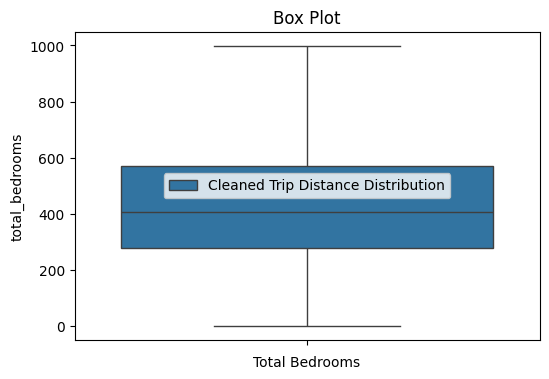

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data['total_bedrooms'])
plt.title("Box Plot")
plt.xlabel("Total Bedrooms")
plt.legend(["Cleaned Trip Distance Distribution"])


plt.show()

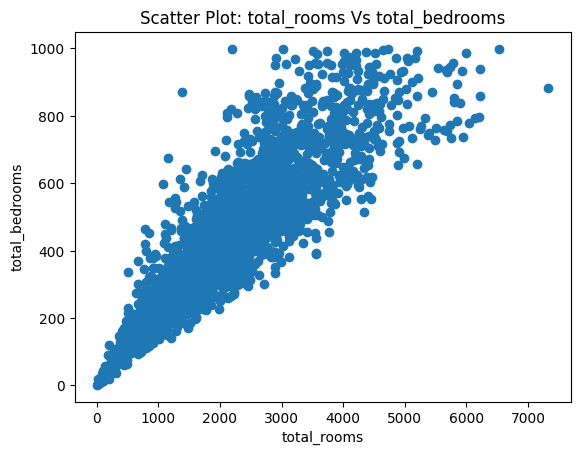

In [ ]:
plt.figure()
plt.scatter(data["total_rooms"], data["total_bedrooms"])
plt.xlabel("total_rooms")
plt.ylabel("total_bedrooms")
plt.title("Scatter Plot: total_rooms Vs total_bedrooms")

plt.show()

In [ ]:
X = df[['total_bedrooms']]
y = df['total_rooms']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: -26.038065501344136
Slope: 4.941197280688733


In [ ]:
df['predicted'] = model.predict(X)
print(df)

     longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0      -122.05     37.37                27.0       3885.0           661.0   
1      -118.30     34.26                43.0       1510.0           310.0   
2      -117.81     33.78                27.0       3589.0           507.0   
3      -118.36     33.82                28.0         67.0            15.0   
4      -119.67     36.33                19.0       1241.0           244.0   
..         ...       ...                 ...          ...             ...   
995    -119.33     36.31                15.0       1472.0           228.0   
996    -118.41     34.21                35.0       1789.0           292.0   
997    -119.50     34.35                39.0        308.0            38.0   
998    -118.33     34.11                48.0       1601.0           464.0   
999    -118.30     34.10                29.0       3403.0          1367.0   

     population  households  median_income  median_house_value  \
0        

/tmp/ipython-input-325947996.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['predicted'] = model.predict(X)


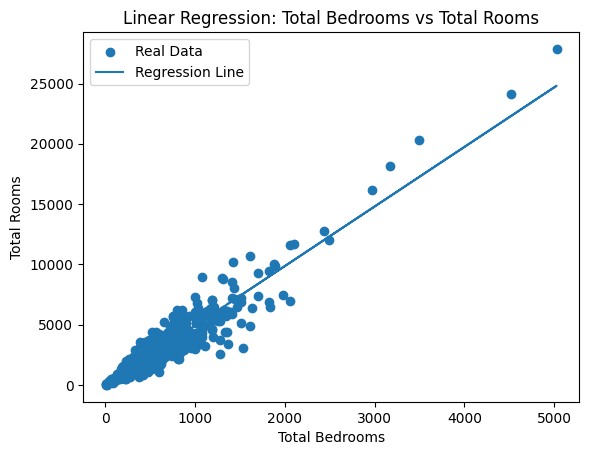

In [ ]:
plt.figure()

plt.scatter(df['total_bedrooms'], df['total_rooms'], label="Real Data")

plt.plot(df['total_bedrooms'], df['predicted'], label="Regression Line")

plt.xlabel("Total Bedrooms")
plt.ylabel("Total Rooms")
plt.title("Linear Regression: Total Bedrooms vs Total Rooms")
plt.legend()
plt.show()


In [ ]:
Q1 = df['total_bedrooms'].quantile(0.25)
Q3 = df['total_bedrooms'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['total_bedrooms'] >= lower) & (df['total_bedrooms'] <= upper)]


/tmp/ipython-input-3690293636.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['predicted'] = model.predict(X)


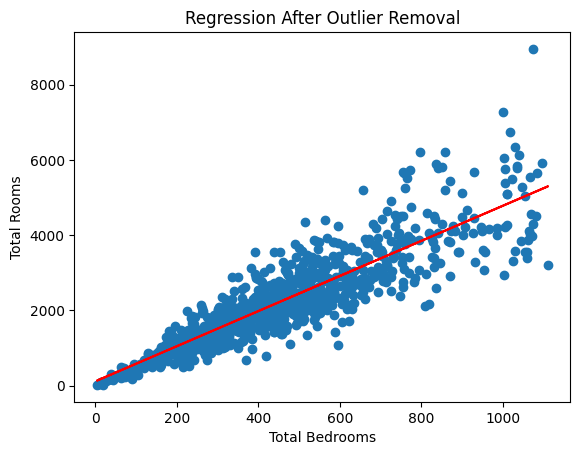

In [ ]:
X = df[['total_bedrooms']]
y = df['total_rooms']

model = LinearRegression()
model.fit(X, y)

df['predicted'] = model.predict(X)

plt.scatter(df['total_bedrooms'], df['total_rooms'])
plt.plot(df['total_bedrooms'], df['predicted'],color="red")
plt.xlabel("Total Bedrooms")
plt.ylabel("Total Rooms")
plt.title("Regression After Outlier Removal")
plt.show()
